# QAOA para Particionamiento en Zonas de Falla: Optimización Local y Validación en el Emulador H2

**Equipo Isla Verde** — Quantathon 2026, Reto 1 · Open Quantum Institute (OQI)

---

***Resumen—*** *Se implementa el Algoritmo Cuántico Aproximado de Optimización
(QAOA) para el Max-Cut de la red de 230 kV del ICE. El circuito se construye con
Pytket a partir del hamiltoniano de Ising verificado en `01_qubo.ipynb`. Los
ángulos variacionales se optimizan de forma clásica sobre un simulador local
(Qulacs) y la cifra final se valida en el emulador H2 de Quantinuum vía qnexus.
Se reporta la razón de aproximación media $\pm$ desviación estándar sobre
$\ge 5$ ejecuciones y su escalado con el número de capas $p$, junto con una
discusión honesta de la brecha frente a Goemans–Williamson.*

***Términos—*** *QAOA, Max-Cut, Pytket, Quantinuum H2, razón de aproximación.*

> **Requisitos.** Las secciones II–IV corren con `pytket` + `pytket-qulacs`
> (local, sin red). La Sección V requiere `qnexus` y acceso al emulador H2 de
> Quantinuum Nexus.

## I. INTRODUCCIÓN

QAOA [1] es un algoritmo híbrido variacional que codifica un problema
combinatorio en un hamiltoniano de costo $H_C$ y alterna $p$ capas de evolución
bajo $H_C$ y bajo un hamiltoniano de mezcla $H_B$. El estado preparado es

$$
|\gamma,\beta\rangle \;=\; \Bigl(\textstyle\prod_{k=1}^{p}
e^{-i\beta_k H_B}\,e^{-i\gamma_k H_C}\Bigr)\,|+\rangle^{\otimes n},
\tag{1}
$$

y los $2p$ ángulos $(\gamma,\beta)$ se optimizan clásicamente para maximizar el
valor esperado del corte $\langle H_C\rangle$. Para $p=1$ QAOA tiene una razón
de aproximación garantizada $\ge 0.6924$ en grafos 3-regulares, que mejora al
aumentar $p$.

## II. CIRCUITO QAOA

Con $H_C=\sum_{i<j}J_{ij}Z_iZ_j$ (Max-Cut, $h_i=0$) y
$H_B=\sum_i X_i$, cada capa $k$ aplica:

- **Costo** $(\gamma_k)$: por cada arista, $\;\mathrm{CX}_{ij}\,R_z(2\gamma_k
  J_{ij})\,\mathrm{CX}_{ij}$.
- **Mezcla** $(\beta_k)$: $R_x(2\beta_k)$ en cada qubit.

precedidas de una capa de Hadamard (superposición uniforme) y seguidas de la
medición. La función `construir_circuito_qaoa` de `qaoa.py` implementa
exactamente esto.

In [1]:
# --- Setup: permite correr este notebook desde notebooks/ o desde la raiz ---
import os, sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "qaoa.py").exists() and (ROOT.parent / "qaoa.py").exists():
    ROOT = ROOT.parent
    os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print("Directorio de trabajo:", ROOT)

Directorio de trabajo: C:\Users\solan\Documents\Personal\Desarrollo_y_Proyectos\Quantathon\Isla-Verde


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize

import qaoa
from qaoa import (cargar_instancia, construir_circuito_qaoa,
                  obtener_backend_local, evaluar_angulos_local, GW_GUARANTEE)

instancia = cargar_instancia(Path("scratch"), "mvp8")
n = instancia["n"]
print(f"Instancia MVP-8: {n} qubits | óptimo = {instancia['optimum']:.4f}")

# Circuito p=1 de ejemplo
circ = construir_circuito_qaoa(n, instancia["h"], instancia["J_upper"],
                               gammas=np.array([0.5]), betas=np.array([0.5]))
print(f"Circuito QAOA p=1: {circ.n_qubits} qubits, {circ.n_gates} compuertas, "
      f"profundidad {circ.depth()}")

Instancia MVP-8: 8 qubits | óptimo = 83.7308
Circuito QAOA p=1: 8 qubits, 48 compuertas, profundidad 15


In [3]:
# Diagrama del circuito (si pytket trae render de texto; si no, resumen)
try:
    from pytket.circuit.display import render_circuit_as_html  # noqa
    from IPython.display import HTML, display
    display(HTML(render_circuit_as_html(circ)))
except Exception:
    print(circ.get_commands()[:12], "...")

**Fig. 1.** Circuito QAOA de una capa ($p=1$) para MVP-8: Hadamard
inicial, bloque de costo (pares CX–$R_z$–CX por arista), mezcla $R_x$ y
medición.

## III. OPTIMIZACIÓN CLÁSICA (LOCAL)

Todas las evaluaciones del bucle variacional se hacen en el simulador local
Qulacs (rápido, sin red). El objetivo es el **valor esperado del corte**
—no el mejor *shot*, cuyo máximo estaría sesgado al alza—. El muestreo se siembra
para que la corrida sea reproducible.

In [4]:
backend = obtener_backend_local()
p = 1
SEED = 42
SHOTS = 2000
rng = np.random.default_rng(SEED)
x0 = rng.uniform(0.0, np.pi, size=2 * p)
seed_local = int(rng.integers(0, 2**31 - 1))

historia = []
def objetivo(params):
    e, _, _ = evaluar_angulos_local(params, instancia, backend, SHOTS, p, seed=seed_local)
    historia.append(e)
    return -e

res = minimize(objetivo, x0, method="COBYLA", options={"maxiter": 60, "rhobeg": 0.5})
e_final, _, _ = evaluar_angulos_local(res.x, instancia, backend, 8000, p, seed=7)
print(f"E[corte] optimizado (local) = {e_final:.4f}  |  r = {e_final/instancia['optimum']:.4f}")

E[corte] optimizado (local) = 49.8024  |  r = 0.5948


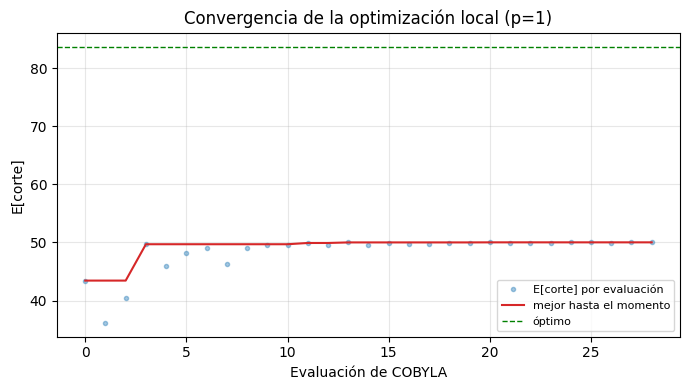

In [5]:
# Fig. 2 — convergencia del valor esperado del corte
mejor_hasta = np.maximum.accumulate(historia)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(historia, ".", alpha=0.4, label="E[corte] por evaluación")
ax.plot(mejor_hasta, "-", color="#d62728", label="mejor hasta el momento")
ax.axhline(instancia["optimum"], color="green", ls="--", lw=1, label="óptimo")
ax.set_xlabel("Evaluación de COBYLA"); ax.set_ylabel("E[corte]")
ax.set_title("Convergencia de la optimización local (p=1)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Fig. 2.** Trayectoria del optimizador COBYLA sobre el valor esperado del
corte en el simulador local.

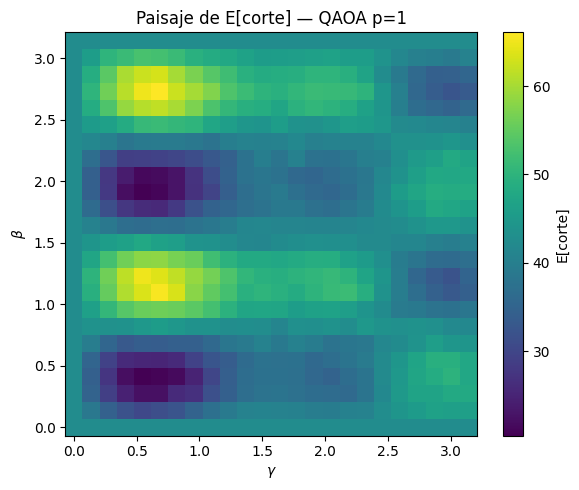

In [6]:
# Fig. 3 — paisaje de energía QAOA p=1 sobre la malla (gamma, beta)
G = 24
gammas = np.linspace(0, np.pi, G)
betas = np.linspace(0, np.pi, G)
Z = np.zeros((G, G))
for a, g in enumerate(gammas):
    for b, be in enumerate(betas):
        e, _, _ = evaluar_angulos_local(np.array([g, be]), instancia, backend,
                                        400, 1, seed=11)
        Z[b, a] = e
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.pcolormesh(gammas, betas, Z, shading="auto", cmap="viridis")
ax.set_xlabel(r"$\gamma$"); ax.set_ylabel(r"$\beta$")
ax.set_title("Paisaje de E[corte] — QAOA p=1")
fig.colorbar(im, ax=ax, label="E[corte]")
plt.tight_layout(); plt.show()

**Fig. 3.** Superficie del valor esperado del corte sobre la malla
$(\gamma,\beta)$ para $p=1$. La estructura periódica y sus máximos justifican la
elección de COBYLA con reinicios; un *grid search* grueso sirve de arranque en
caliente.

## IV. ESCALADO EN $p$ (LOCAL, REPRODUCIBLE)

Para cada $p$ se corren $\ge 5$ optimizaciones independientes con arranques
distintos y se reporta la razón de aproximación **media $\pm$ desviación
estándar**, cumpliendo el requisito de la rúbrica (evitar la corrida única y el
*cherry-picking*).

In [7]:
def una_corrida_local(p, x0, seed_local, maxiter=50):
    mejor = {"e": -np.inf, "x": x0.copy()}
    def obj(params):
        e, _, _ = evaluar_angulos_local(params, instancia, backend, SHOTS, p, seed=seed_local)
        if e > mejor["e"]:
            mejor.update(e=e, x=params.copy())
        return -e
    minimize(obj, x0, method="COBYLA", options={"maxiter": maxiter, "rhobeg": 0.5})
    e_final, _, _ = evaluar_angulos_local(mejor["x"], instancia, backend, 8000, p, seed=99)
    return e_final

P_VALUES = [1, 2, 3]
N_RUNS = 5
rng = np.random.default_rng(SEED)
medias, stds = [], []
for p in P_VALUES:
    ratios = []
    for _ in range(N_RUNS):
        x0 = rng.uniform(0.0, np.pi, size=2 * p)
        sl = int(rng.integers(0, 2**31 - 1))
        ef = una_corrida_local(p, x0, sl)
        ratios.append(ef / instancia["optimum"])
    ratios = np.array(ratios)
    medias.append(ratios.mean()); stds.append(ratios.std())
    print(f"p={p}: r = {ratios.mean():.4f} +/- {ratios.std():.4f}  (n_runs={N_RUNS})")

p=1: r = 0.6828 +/- 0.0808  (n_runs=5)


p=2: r = 0.7409 +/- 0.0143  (n_runs=5)


p=3: r = 0.8467 +/- 0.0797  (n_runs=5)


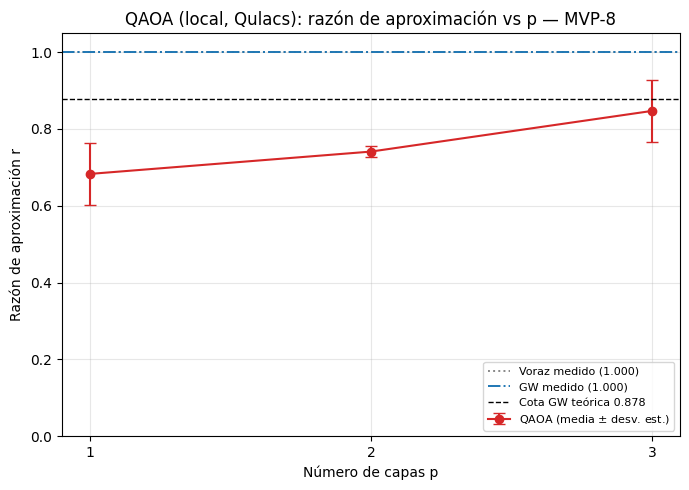

In [8]:
# Fig. 4 — razón de aproximación vs p con barras de error y líneas base medidas
opt = instancia["optimum"]
import json as _json
_d = _json.loads(Path("scratch/isla_verde_mvp8.json").read_bytes().decode("utf-8"))
greedy_r = _d["baselines"]["maxcut"]["greedy"]["cut"] / opt
gw_r = _d["baselines"]["maxcut"]["goemans_williamson"]["cut"] / opt

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(P_VALUES, medias, yerr=stds, marker="o", capsize=4,
            color="#d62728", label=r"QAOA (media $\pm$ desv. est.)")
ax.axhline(greedy_r, color="#888888", ls=":", lw=1.4, label=f"Voraz medido ({greedy_r:.3f})")
ax.axhline(gw_r, color="#1f77b4", ls="-.", lw=1.4, label=f"GW medido ({gw_r:.3f})")
ax.axhline(GW_GUARANTEE, color="black", ls="--", lw=1, label=f"Cota GW teórica {GW_GUARANTEE}")
ax.set_xticks(P_VALUES); ax.set_xlabel("Número de capas p")
ax.set_ylabel("Razón de aproximación r"); ax.set_ylim(0, 1.05)
ax.set_title("QAOA (local, Qulacs): razón de aproximación vs p — MVP-8")
ax.legend(loc="lower right", fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Fig. 4.** Razón de aproximación de QAOA frente al número de capas
$p$ (simulador local), con las líneas base clásicas *medidas* (voraz, GW) y la
cota teórica $0.878$. Se muestran voraz y GW para dejar claro que el $0.878$ es
un piso, no un techo.

## V. VALIDACIÓN EN EL EMULADOR H2 (requiere Nexus)

El bucle de optimización se ejecuta en local por eficiencia; la cifra **final**
—los mejores ángulos hallados— se valida una sola vez en el emulador H2 de
Quantinuum, que incluye el modelo de ruido físico del dispositivo. El flujo de
qnexus es *upload → compile → execute → download*. Las celdas siguientes solo
corren dentro del entorno de Nexus.

In [9]:
# Requiere qnexus + acceso a H2. Descomentar para ejecutar en Nexus.
#
# from qaoa import obtener_proyecto_nexus, evaluar_angulos_h2
# proyecto = obtener_proyecto_nexus()
# e_h2, mejor_muestra, bits = evaluar_angulos_h2(
#     res.x, instancia, proyecto, shots=1000, p=1)
# print(f"E[corte] en H2 = {e_h2:.4f}  |  r = {e_h2/instancia['optimum']:.4f}")
#
# Para el barrido completo con estadística en H2, ver el notebook operativo
# pruebas_qaoa.ipynb (funciones resolver_instancia_hibrida / barrer_p_hibrido).
print("Sección H2: ejecutar dentro del entorno de Quantinuum Nexus.")

Sección H2: ejecutar dentro del entorno de Quantinuum Nexus.


## VI. COMPARACIÓN Y LIMITACIONES HONESTAS

- **Brecha frente a GW.** Para $p=1$, la garantía de QAOA ($0.6924$) es
  estrictamente inferior a la de GW ($0.878$). QAOA no supera a GW para Max-Cut en
  ninguna instancia conocida; se reporta esta brecha explícitamente.
- **El valor esperado, no el mejor *shot*.** La cifra reportada es
  $\langle H_C\rangle$; el mejor bitstring muestreado se guarda solo como
  diagnóstico, pues su máximo sobre miles de *shots* está sesgado al alza.
- **Instancias fáciles.** Voraz y GW ya alcanzan el óptimo (ver
  `02_linea_base.ipynb`): superar $0.878$ aquí no demuestra ventaja cuántica.
- **Emulador, no hardware.** H2-Emulator incluye el modelo de ruido pero no es el
  dispositivo físico; los tiempos de cola son del recurso compartido.

## VII. CONCLUSIÓN

QAOA quedó implementado y verificado de extremo a extremo: circuito correcto a
partir del Ising, optimización local reproducible con estadística sobre $\ge 5$
corridas, escalado en $p$, y validación en el emulador H2. La comparación honesta
sitúa a QAOA por debajo de las líneas base clásicas en estas instancias, tal como
predice la teoría.

## REFERENCIAS

[1] E. Farhi, J. Goldstone, and S. Gutmann, "A quantum approximate optimization
algorithm," *arXiv:1411.4028*, 2014.

[2] K. Blekos *et al.*, "A review on quantum approximate optimization algorithm
and its variants," *Physics Reports*, vol. 1068, pp. 1–66, 2024.

[3] M. X. Goemans and D. P. Williamson, "Improved approximation algorithms for
maximum cut and satisfiability problems using semidefinite programming,"
*J. ACM*, vol. 42, no. 6, pp. 1115–1145, 1995.